# Data exploration

In [3]:
import pandas as pd

from protest_impact.data.news.download import get_counts
from protest_impact.util import project_root

count_df_path = project_root / "data" / "news" / "monthly_counts.csv"
if count_df_path.exists():
    df = pd.read_csv(count_df_path)
else:
    df = get_counts()
    df.to_csv(count_df_path, index=False)
df["date"] = pd.to_datetime(df["date"])
df.head()

,newspaper,engine,date,count
0,abendblatt.de,google,2013-01-01,134
1,abendblatt.de,google,2013-02-01,122
2,abendblatt.de,google,2013-03-01,89
3,abendblatt.de,google,2013-04-01,133
4,abendblatt.de,google,2013-05-01,122


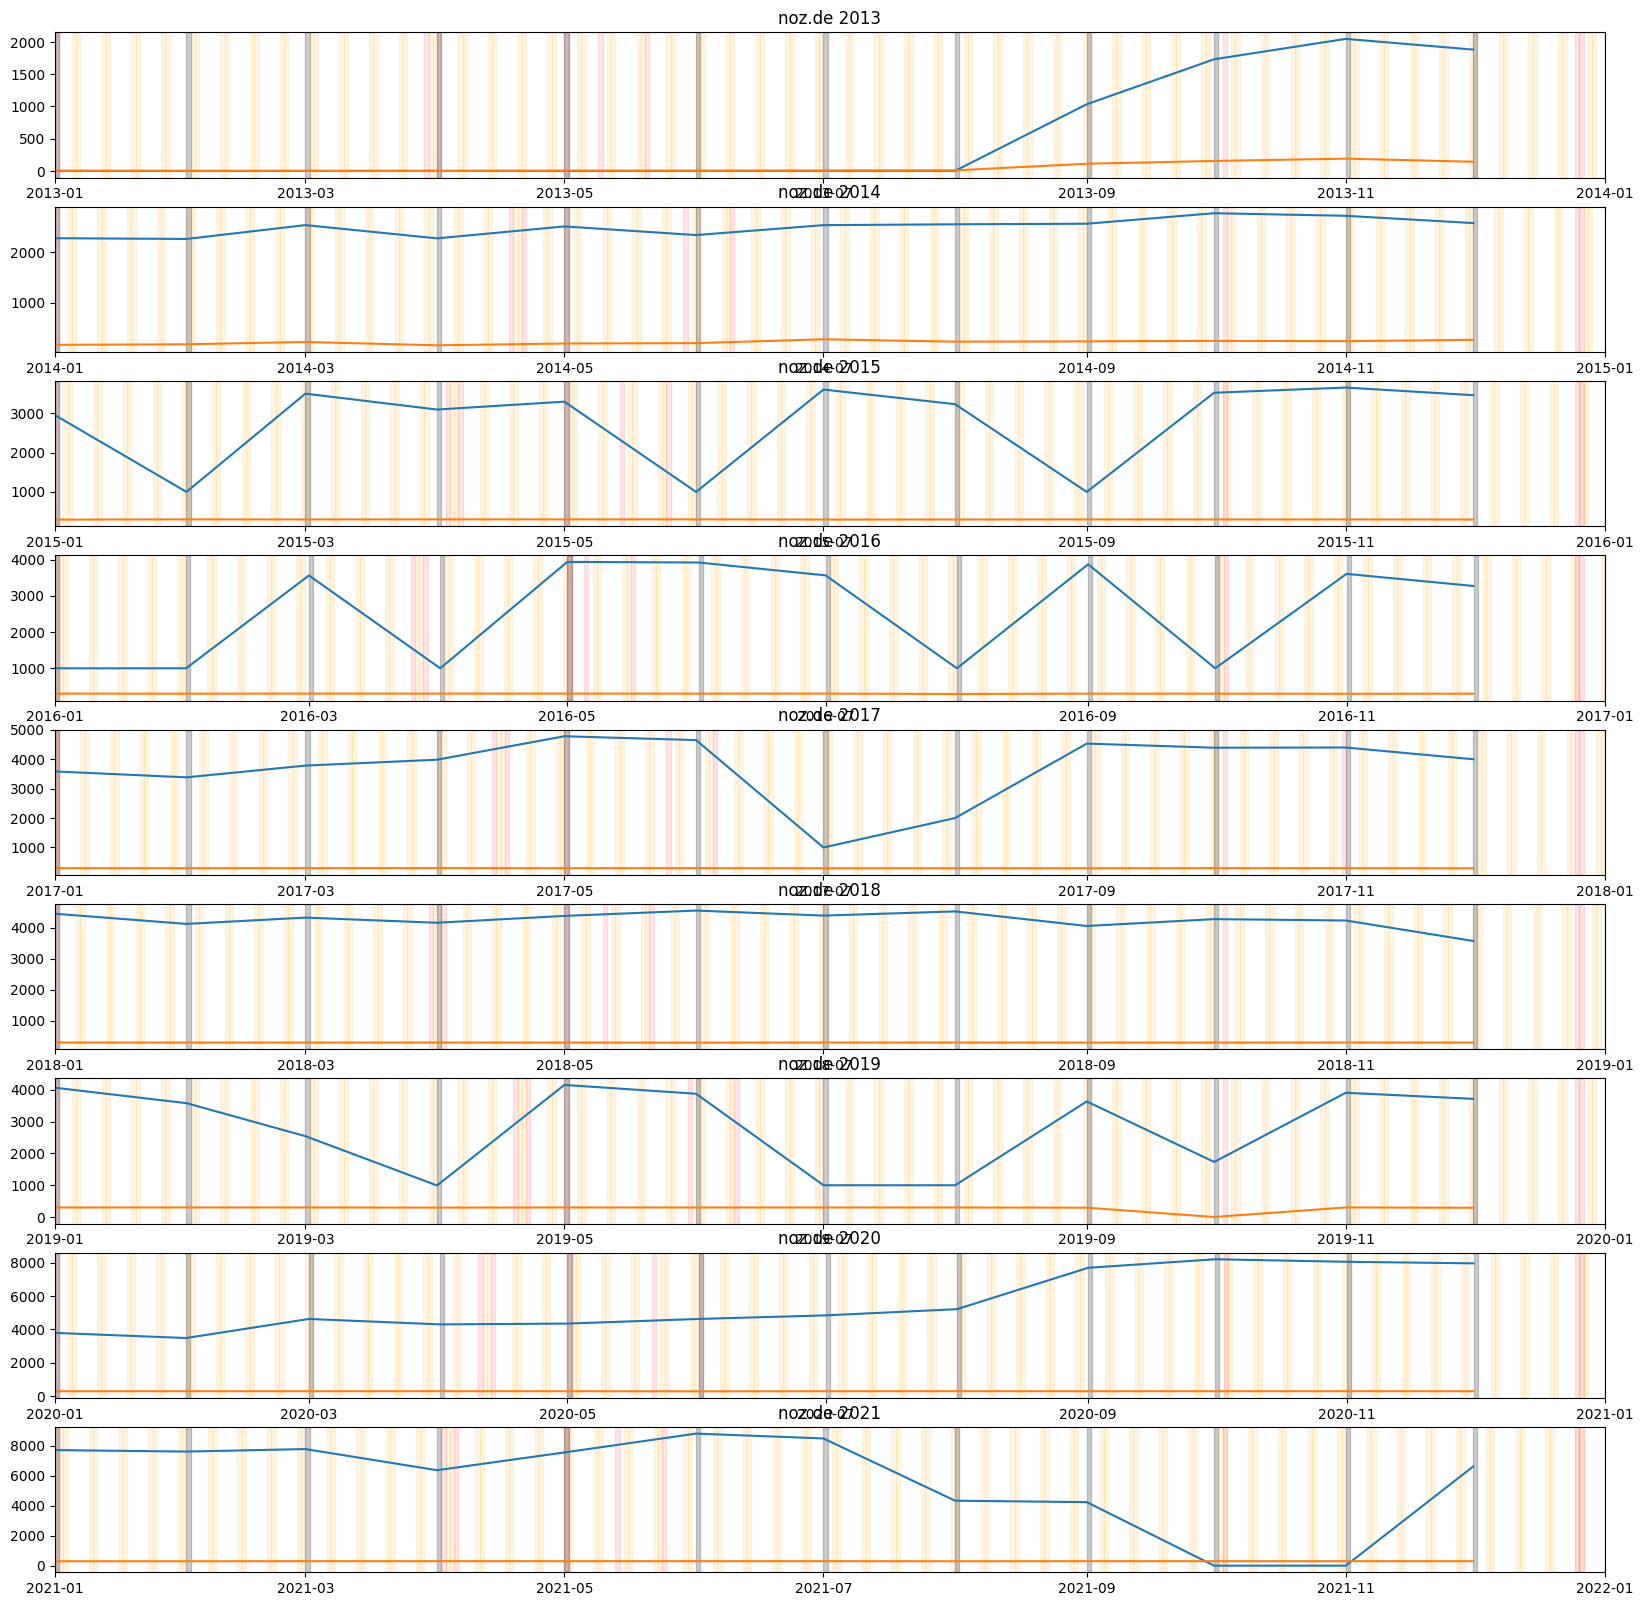

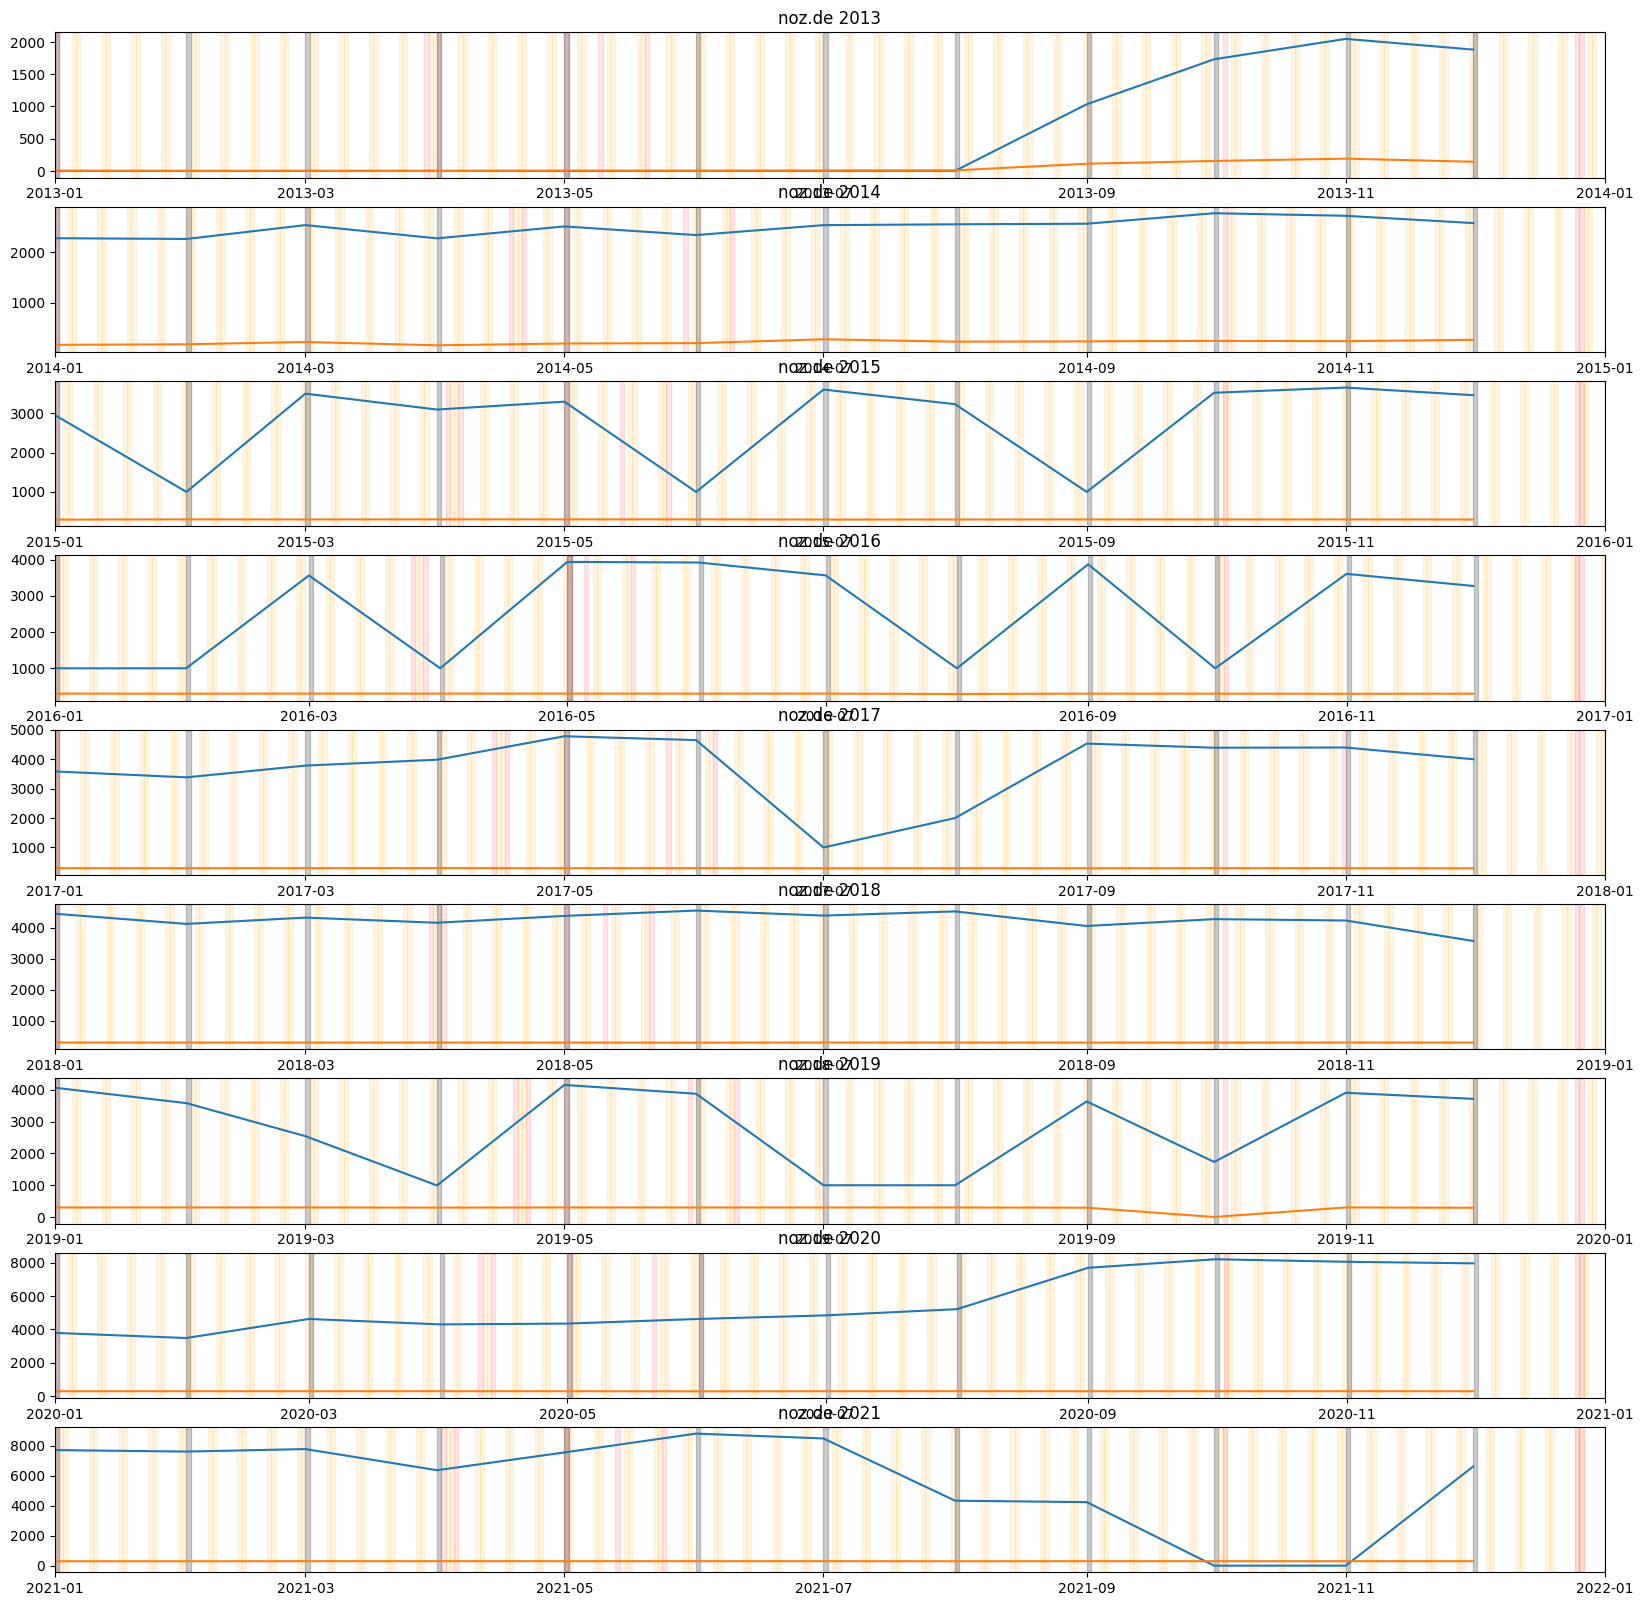

In [4]:
import matplotlib.pyplot as plt

from protest_impact.data.plot_history import plot_history

plt.close()
plot_history(df, newspaper="noz.de")

<AxesSubplot: >

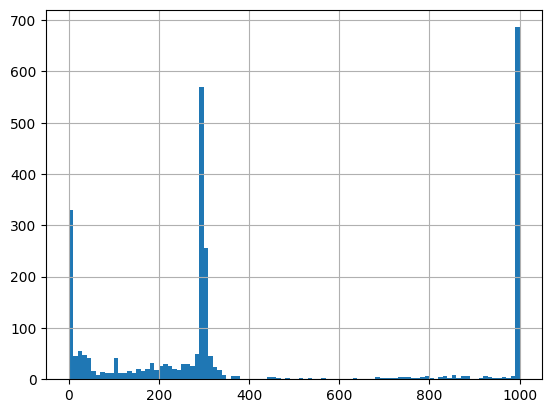

In [5]:
df_ = df.copy()
# aggregate the data by month (for each year) and newspaper
df_["month"] = df_["date"].dt.strftime("%Y-%m")
df_ = df_.groupby(["newspaper", "month"])["count"].sum().reset_index()
# plot the distribution of the number of articles per month
# cap the number of articles at 1000
df_["count"] = df_["count"].clip(upper=1000)
df_["count"].hist(bins=100)

<AxesSubplot: >

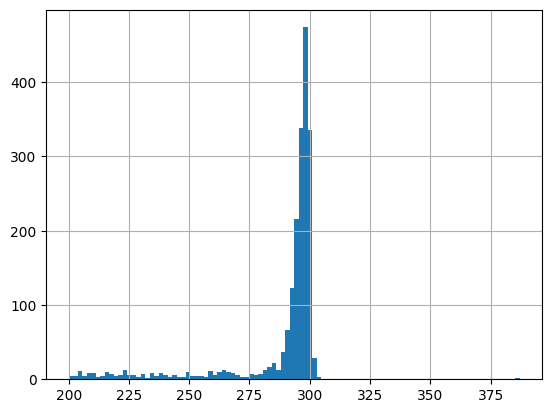

In [6]:
# plot the distribution for the values 200 to 400
df["count"][df["count"].between(200, 400)].hist(bins=100)